# Phase E: Quality masking and per-image FLIM statistics

This notebook does NOT perform curve fitting.  The fluorescence lifetime decays
were fitted in SPCImage (Becker & Hickl) using iterative reconvolution with the
experimentally measured IRF.  Phase E imports per-pixel parameter maps that
SPCImage exported as .asc text grids and applies post-hoc quality masking and
summary statistics.

-----------------------------------------------------------------------
What was fitted, and how
-----------------------------------------------------------------------

glu (glutaraldehyde-fixed cells)
  Model: 3-component exponential decay, I(t) = a1*exp(-t/tau1)
                                               + a2*exp(-t/tau2)
                                               + a3*exp(-t/tau3)
  SPCImage sorts components by lifetime (tau1 < tau2 < tau3), so:
    a1, tau1 : ultra-short glutaraldehyde fixation artifact (~16-30 ps)
    a2, tau2 : free NADH, shorter-lived component (~300-700 ps)
    a3, tau3 : protein-bound NADH, longer-lived component (~1500-3000 ps)
  Amplitudes are fractional (SPCImage normalises so a1+a2+a3 = 1).
  IRF shift: fixed to zero for most acquisitions; some files used a free
  shift (see shift_group column derived from Phase C).

form (formaldehyde-fixed cells), live
  Model: 2-component exponential decay.
    a1, tau1 : free NADH
    a2, tau2 : protein-bound NADH
  Amplitudes normalised (a1+a2 = 1).

-----------------------------------------------------------------------
Spatial binning
-----------------------------------------------------------------------
SPCImage sums the decay photons over a (2b+1)x(2b+1) box kernel before
fitting (bin radius b encoded in the fit folder name, e.g. "b5" => b=5,
kernel 11x11).  The exported per-pixel parameter maps assign the fit
result to every pixel in the binned neighbourhood.  Consequently:
  - The photon threshold in criterion 1 is applied to the BINNED total
    (approximated as uniform_filter(photons, 2b+1) * (2b+1)^2).
  - Neighbouring pixels within one kernel radius share the same fit result
    and are not statistically independent.

-----------------------------------------------------------------------
Per-pixel quality criteria -- ALL must pass (Step 15)
-----------------------------------------------------------------------
1. Binned photon count >= MIN_PHOTONS_BY_NCOMP
     3-comp : 8,000 photons   (more components need more photons)
     2-comp : 3,000 photons
     1-comp :   500 photons
     unknown: 3,000 photons
   If photons.asc is absent, SDT file is loaded as fallback.
   If neither is available, ALL pixels pass this criterion.

2. Reduced chi-squared: CHI2_LO <= chi^2 <= CHI2_HI  [0.8, 2.0]
     chi^2 < 0.8 : over-fitting or too few photons (Poisson noise dominated)
     chi^2 > 2.0 : systematic model mismatch or poor convergence
   If chi.asc is absent, ALL pixels pass.

3. Amplitude positivity: every exported amplitude component (a1, a2, a3
   where present) >= 0, AND their sum > 0.
   SPCImage zero-fills pixels where the fit did not converge.

4. Tau physical bounds (TAU_BOUNDS, ps):
     glu  : tau1 in [0, 200]    -- artifact; tau1 > 200 ps means the
                                   fit did not resolve the artifact component
            tau2 in [50, 1200]  -- free NADH
            tau3 in [800, 6000] -- bound NADH
     form : tau1 in [50, 1500]  -- free NADH
            tau2 in [800, 6000] -- bound NADH
     live : same as form
   Any pixel where a present tau component falls outside its bound is rejected.

5. tau_mean physical bounds (TAU_MEAN_BOUNDS, ps):
     live ONLY: tau_mean >= 250 ps
     glu, form: no tau_mean filter applied
   Motivation for live: removes punctate very-short-lifetime pixels
   (lipid droplets, collapsed fits) without tightening component bounds.
   CAUTION: this is an ASYMMETRIC criterion -- live data has an extra
   exclusion not applied to glu or form.  Verify this does not bias
   live comparisons relative to fixed conditions.

-----------------------------------------------------------------------
Output metrics (quality-masked pixels only)
-----------------------------------------------------------------------
tau_mean (ps): amplitude-weighted mean lifetime, excluding artifact.
  glu  : (a2*tau2 + a3*tau3) / (a2+a3)
         a1/tau1 are EXCLUDED from this average.
         CAUTION: if a3/tau3 are absent (2-comp fallback file), compute_tau_mean
         returns None and the file contributes NaN to tau_mean columns.
         Such files are silently absent from tau_mean comparisons.
  form, live: (a1*tau1 + a2*tau2) / (a1+a2)

amp_ratio (unitless): RATIO of two amplitude components (NOT a fraction).
  glu  : a2 / a3   (free NADH amplitude / bound NADH amplitude)
  form, live: a1 / a2
  Typical ranges: glu a2/a3 ~ 1-5;  form/live a1/a2 ~ 0.5-2.
  VALUES CAN EXCEED 1.  To obtain the normalised free-NADH fraction use
  num / (num + den) on the raw amplitude maps.
  CAUTION: Step 17 histogram and groups notebook violin plots display
  this ratio on its natural scale, not clamped to [0, 1].

-----------------------------------------------------------------------
Exclusions written to fit_analysis_summary.csv (Step 18)
-----------------------------------------------------------------------
- Files with < 1% pixel retention are logged in low_retention_warnings.txt
  and EXCLUDED from fit_analysis_summary.csv.
- glu files where tau_mean = NaN (2-comp fallback) appear in the CSV
  but contribute NaN to tau_mean columns.
- n_components is stored as an explicit integer column (parsed from the
  fit folder name by parse_fit_folder).  Phase F reads this column
  directly; it no longer needs to re-parse fit_set_key strings.

-----------------------------------------------------------------------
Steps
-----------------------------------------------------------------------
14. Load Phase A/B outputs; define helpers
15. Quality masking (all fit sets) -> {base_stem}_fit_mask.npy per folder
    15b. Failure diagnosis
    15c. Chi^2 distribution check
16. tau_mean spatial maps (preferred fit model per file)
17. tau_mean and amplitude ratio distributions (split by shift_group x n_comp)
18. Per-file summary stats -> results/fit_analysis_summary.csv

FORCE_RECOMPUTE must be True whenever TAU_BOUNDS, CHI2_LO/HI, or
MIN_PHOTONS_BY_NCOMP are changed; otherwise cached .npy masks are reused.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter
from sdtfile import SdtFile

# -- Configuration ----------------------------------------------------------
WIN_DATA_DIRS = [
    Path(r"E:\18_RK_Circadian\data\raw\20260429_KPC_fixed_dishes_on_SLIM"),
    Path(r"E:\18_RK_Circadian\data\raw\20260501_KPC_fixed_dishes_on_SLIM"),
    Path(r"E:\18_RK_Circadian\data\raw\20260509_KPC_fixed_dishes_on_SLIM"),
    Path(r"E:\18_RK_Circadian\data\raw\20260508_KPC_live_on_SLIM"),
    Path(r"E:\18_RK_Circadian\data\raw\20260517_KPC_live_on_SLIM"),
    Path(r"E:\18_RK_Circadian\data\raw\20260520_KPC_fixed_dishes_SLIM"),
    Path(r"E:\18_RK_Circadian\data\raw\20260521_KPC_live_SLIM"),
    Path(r"E:\18_RK_Circadian\data\raw\20260522_KPC_fixed_dishes_SLIM"),
]
LIN_DATA_DIRS = [
    Path("/media/mint/BRPresbkup/18_RK_Circadian/data/raw/20260429_KPC_fixed_dishes_on_SLIM"),
    Path("/media/mint/BRPresbkup/18_RK_Circadian/data/raw/20260501_KPC_fixed_dishes_on_SLIM"),
    Path("/media/mint/BRPresbkup/18_RK_Circadian/data/raw/20260509_KPC_fixed_dishes_on_SLIM"),
    Path("/media/mint/BRPresbkup/18_RK_Circadian/data/raw/20260508_KPC_live_on_SLIM"),
    Path("/media/mint/BRPresbkup/18_RK_Circadian/data/raw/20260517_KPC_live_on_SLIM"),
    Path("/media/mint/BRPresbkup/18_RK_Circadian/data/raw/20260520_KPC_fixed_dishes_SLIM"),
    Path("/media/mint/BRPresbkup/18_RK_Circadian/data/raw/20260521_KPC_live_SLIM"),
    Path("/media/mint/BRPresbkup/18_RK_Circadian/data/raw/20260522_KPC_fixed_dishes_SLIM"),
]
CURRENT_OS = "Win"
data_dirs = WIN_DATA_DIRS if CURRENT_OS == "Win" else LIN_DATA_DIRS

# Minimum total photon count in the SPCImage-binned region (sum over the
# (2b+1)^2 neighbourhood), per number of fit components.
# More components require more photons for reliable parameter separation.
# None is the fallback when n_components is not parseable from the folder name.
MIN_PHOTONS_BY_NCOMP = {
    1:     500,
    2:   1_000,    # lowered from 3000 to recover dim BKO acquisitions
    3:   8_000,
    None: 1_000,
}

# Chi^2 acceptance window
CHI2_LO = 0.8
CHI2_HI = 2.0

# Tau bounds per fixation_type, in PICOSECONDS (ps).
# SPCImage reports lifetimes in ps. Adjust after inspecting Phase C distributions.
#   glu:  tau1 is the ~16 ps glutaraldehyde artifact;
#         tau2/tau3 are free/bound NADH
#   form/live: tau1 = free NADH, tau2 = bound NADH
TAU_BOUNDS = {
    "glu": {
        "tau1": (0.0,    200.0),    # ultra-short glutaraldehyde artifact component
        "tau2": (50.0,  1200.0),    # free NADH
        "tau3": (800.0, 6000.0),    # bound NADH
    },
    "form": {
        "tau1": (50.0,  1500.0),    # free NADH
        "tau2": (800.0, 6000.0),    # bound NADH
    },
    "live": {
        "tau1": (50.0,  1500.0),
        "tau2": (800.0, 6000.0),
    },
}

# Amplitude-weighted tau_mean components per fixation_type.
# Pairs of (amplitude_key, lifetime_key) to include in the weighted average.
#   glu:       (a2*tau2 + a3*tau3) / (a2+a3)  -- skip ultra-short artifact a1
#   form/live: (a1*tau1 + a2*tau2) / (a1+a2)
TAUMEAN_CFG = {
    "glu":  (("a2", "tau2"), ("a3", "tau3")),
    "form": (("a1", "tau1"), ("a2", "tau2")),
    "live": (("a1", "tau1"), ("a2", "tau2")),
}

# Per-pixel amplitude-weighted tau_mean bounds (ps).
# Pixels outside this range are excluded even if all other criteria pass.
# Use (lo, None) or (None, hi) to set only one side.
# Primary use: remove punctate low-tau artifacts in live images (lipid droplets,
# collapsed fits) without tightening individual component bounds.
# Set the value to None to skip tau_mean filtering for that fixation type.
TAU_MEAN_BOUNDS = {
    "glu":  None,
    "form": None,
    "live": (250.0, None),
}

# Amplitude ratio (numerator component, denominator component)
# glu: a2/(a2+a3) -- free/total NADH excluding the artifact component
RATIO_CFG = {
    "glu":  ("a2", "a3"),
    "form": ("a1", "a2"),
    "live": ("a1", "a2"),
}

# Preferred number of fit components per fixation_type (for Steps 16-18)
PREFERRED_N_COMP = {"glu": 3, "form": 2, "live": 2}

# Per-session bin-radius override.  When a session was re-exported in SPCImage
# at a specific bin to recover dim acquisitions, list it here.  best_fit_key()
# restricts candidates to that bin before applying n_comp and shift preferences.
# Only affects listed sessions; all other sessions use their normal fit selection.
PREFERRED_BIN_OVERRIDE = {
    "20260509_KPC_fixed_dishes_on_SLIM": 10,
}

## Step 14: Load outputs and define helpers

In [2]:
results_dir = Path("../results")

sdt_df = pd.read_csv(results_dir / "sdt_metadata_cal.csv")
fp_map = pd.read_csv(results_dir / "filepath_map.csv")
sdt_df = sdt_df.merge(fp_map[["filename", "filepath"]], on="filename", how="left")
sdt_df["filepath"]         = sdt_df["filepath"].map(Path)
sdt_df["acquisition_time"] = pd.to_datetime(sdt_df["acquisition_time"])

fit_map_df = pd.read_csv(results_dir / "fit_map.csv")

print(f"Loaded {len(sdt_df)} SDT files")
print(f"Loaded fit_map: {len(fit_map_df)} fit-set/SDT pairs")
if "n_components" in fit_map_df.columns:
    print(fit_map_df["n_components"].value_counts().sort_index().to_string())

Loaded 720 SDT files
Loaded fit_map: 3069 fit-set/SDT pairs
n_components
1       8
2    1682
3    1379


In [3]:
# -- Helpers: import from src/io.py (was inline) ----------------------------
import sys as _sys
_sys.path.insert(0, str(Path("..").resolve()))
from src.io import (
    _infer_param_name,
    _strip_param_suffix,
    load_asc_fit_set,
    parse_fit_folder,
    fit_dir_from_key as _lib_fit_dir_from_key,
    load_saved_mask as _lib_load_saved_mask,
)

# Thin wrappers bake in this notebook's data_dirs so call sites stay 1-arg.
def fit_dir_from_key(fit_set_key: str):
    return _lib_fit_dir_from_key(fit_set_key, data_dirs)

def load_saved_mask(fit_set_key: str):
    return _lib_load_saved_mask(fit_set_key, data_dirs)


# -- Helpers: import from src/fitting.py and src/metrics.py (was inline) ----
from src.fitting import (
    _parse_bin_radius,
    _prefer_shift_zero,
    best_fit_key as _lib_best_fit_key,
    compute_fit_mask as _lib_compute_fit_mask,
)
from src.metrics import compute_tau_mean as _lib_compute_tau_mean

# Thin wrappers bake in this notebook's config dicts so call sites stay unchanged.
def best_fit_key(filename, fixation_type=None):
    return _lib_best_fit_key(
        filename, fit_map_df,
        fixation_type=fixation_type,
        preferred_n_comp=PREFERRED_N_COMP,
    )

def compute_fit_mask(fd, fixation_type, b_val, sdt_photons=None, n_components=None):
    return _lib_compute_fit_mask(
        fd, fixation_type, b_val, sdt_photons, n_components,
        min_photons_by_ncomp=MIN_PHOTONS_BY_NCOMP,
        chi2_lo=CHI2_LO, chi2_hi=CHI2_HI,
        tau_bounds=TAU_BOUNDS,
        tau_mean_bounds=TAU_MEAN_BOUNDS,
        taumean_cfg=TAUMEAN_CFG,
    )

def compute_tau_mean(fd, fixation_type):
    return _lib_compute_tau_mean(fd, fixation_type, taumean_cfg=TAUMEAN_CFG)

## Step 15: Quality masking -- all fit sets

Processes every fit set for sample files. Each fit set gets:
  - {base_stem}_fit_mask.npy saved in the fit export folder
  - A row in fit_quality_summary.csv (per folder) and fit_mask_summary.csv (global)

All fit attempts (2-comp, 3-comp, etc.) are processed independently so that
each export folder contains its own mask for the specific fit configuration.

In [4]:
# Set True to ignore the cache and reprocess every fit set from scratch.
# Needed when TAU_BOUNDS, CHI2_LO/HI, or MIN_PHOTONS_BY_NCOMP change.
FORCE_RECOMPUTE = True

# If True, only files whose best_fit_key resolves to a shift-zero (sz) folder
# are included in Steps 16-18 and written to fit_analysis_summary.csv.
# Files with only shift-free (sf) fits are skipped with a printed warning.
# Set False to fall back to sf fits when no sz folder exists.
REQUIRE_SHIFT_ZERO = True

sample_filenames = set(sdt_df.loc[sdt_df["file_type"] == "sample", "filename"])
sample_key_rows  = fit_map_df[fit_map_df["sdt_filename"].isin(sample_filenames)]
sample_keys      = sorted(set(sample_key_rows["fit_set_key"]))
print(f"Unique fit sets to process: {len(sample_keys)}")

# Load existing summary as cache
_summary_path = results_dir / "fit_mask_summary.csv"
if not FORCE_RECOMPUTE and _summary_path.exists():
    _cache_df = pd.read_csv(_summary_path).set_index("fit_set_key")
    print(f"  Cache: {len(_cache_df)} existing entries in fit_mask_summary.csv")
else:
    _cache_df = pd.DataFrame()

# Build fast lookups
fn_to_meta = sdt_df.set_index("filename")[["filepath", "fixation_type"]].to_dict("index")
key_to_fn  = (
    sample_key_rows.groupby("fit_set_key")["sdt_filename"].first().to_dict()
)

mask_summary_rows = []
n_cached = 0
n_computed = 0
_low_ret_log = []   # (sdt_filename, fit_folder, b_val, pct_final)

for fit_set_key in sample_keys:
    fit_dir, session_root, rel_dir, base_stem = fit_dir_from_key(fit_set_key)
    if fit_dir is None or not fit_dir.exists():
        print(f"  [SKIP] fit dir not found: {fit_set_key[:60]}")
        continue

    mask_npy = fit_dir / f"{base_stem}_fit_mask.npy"

    # Cache hit: .npy on disk and summary row present
    if (not FORCE_RECOMPUTE
            and mask_npy.exists()
            and fit_set_key in _cache_df.index):
        row_dict = _cache_df.loc[fit_set_key]
        # loc returns a DataFrame when index is non-unique; take first row
        if isinstance(row_dict, pd.DataFrame):
            row_dict = row_dict.iloc[0]
        row_dict = row_dict.to_dict()
        row_dict["fit_set_key"] = fit_set_key   # index not included in to_dict()
        mask_summary_rows.append(row_dict)
        n_cached += 1
        continue

    # Cache miss: load .asc files and recompute
    folder_meta   = parse_fit_folder(Path(rel_dir).name)
    b_val         = folder_meta["b_val"]
    shift_free    = folder_meta["shift_free"]
    sdt_filename  = key_to_fn.get(fit_set_key)
    sdt_meta      = fn_to_meta.get(sdt_filename, {}) if sdt_filename else {}
    fixation_type = sdt_meta.get("fixation_type")
    sdt_path      = sdt_meta.get("filepath")

    fd = load_asc_fit_set(fit_dir, base_stem)
    if not fd:
        print(f"  [SKIP] no .asc files loaded: {base_stem}")
        continue

    sdt_photons = None
    if "photons" not in fd and sdt_path:
        try:
            sdt_obj     = SdtFile(str(sdt_path))
            sdt_photons = sdt_obj.data[0].astype(float).sum(axis=2)
        except Exception:
            pass

    mask, breakdown = compute_fit_mask(fd, fixation_type, b_val, sdt_photons,
                                       n_components=folder_meta.get("n_components"))
    np.save(str(mask_npy), mask)

    pct_final = breakdown.get("pct_final", 100.0)
    if pct_final < 1.0:
        _low_ret_log.append((sdt_filename or base_stem, rel_dir, b_val, pct_final))

    mask_summary_rows.append({
        "fit_set_key":   fit_set_key,
        "sdt_filename":  sdt_filename,
        "session_root":  session_root,
        "fit_folder":    rel_dir,
        "base_stem":     base_stem,
        "b_val":         b_val,
        "shift_free":    shift_free,
        "fixation_type": fixation_type,
        **breakdown,
    })
    n_computed += 1

    if n_computed % 20 == 0:
        n_tot = breakdown.get("n_total", 1) or 1
        def _pct(k): return round(100.0 * breakdown.get(k, 0) / n_tot)
        print(f"  computed {n_computed}  {base_stem[:32]}"
              f"  ph={_pct('n_photon_ok')}%"
              f"  chi2={_pct('n_chi2_ok')}%"
              f"  amp={_pct('n_amp_ok')}%"
              f"  tau={_pct('n_tau_ok')}%"
              f"  taum={_pct('n_taumean_ok')}%"
              f"  kept={breakdown.get('pct_final', '?')}%")

mask_summary_df = pd.DataFrame(mask_summary_rows)
print(f"\nDone: {len(mask_summary_df)} fit sets  "
      f"({n_cached} cached, {n_computed} newly computed)")

# Files where < 1% of pixels passed all quality criteria.
# These should be re-fit with a higher bin value (larger b_val) before analysis.
_low_ret_path = results_dir / "low_retention_warnings.txt"
if _low_ret_log:
    print(f"\n[WARNING] {len(_low_ret_log)} fit set(s) with <1% pixels accepted"
          f" -- written to {_low_ret_path}")
    with open(str(_low_ret_path), "w") as _f:
        _f.write("# Fit sets with <1% pixel retention -- re-fit with higher b_val\n")
        _f.write("# Generated by Phase E Step 15\n\n")
        for _fn, _folder, _b, _pct in _low_ret_log:
            _msg = f"pct={_pct:.2f}%  b={_b}  folder={_folder}  file={_fn}"
            print(f"  [LOW RETENTION] {_msg}")
            _f.write(_msg + "\n")
else:
    if _low_ret_path.exists():
        _low_ret_path.unlink()   # clean up stale log from previous run
    print("  No low-retention fit sets (all >= 1%).")

# Build set of fit_set_keys with <1% retention for downstream filtering.
_low_ret_keys = set()
if not mask_summary_df.empty and "pct_final" in mask_summary_df.columns:
    _low_ret_keys = set(
        mask_summary_df.loc[mask_summary_df["pct_final"] < 1.0, "fit_set_key"]
    )

# Write fit_quality_summary.csv in each fit folder
for (session_root, fit_folder), grp in mask_summary_df.groupby(
    ["session_root", "fit_folder"]
):
    session_dir = next((d for d in data_dirs if d.name == session_root), None)
    if session_dir is None:
        continue
    out_path = session_dir / Path(fit_folder) / "fit_quality_summary.csv"
    cols_drop = ["session_root", "fit_folder", "fit_set_key"]
    grp.drop(columns=cols_drop, errors="ignore").to_csv(out_path, index=False)

# Global summary
mask_summary_df.to_csv(results_dir / "fit_mask_summary.csv", index=False)
print(f"Saved global mask summary -> {results_dir / 'fit_mask_summary.csv'}")

# Retention statistics by fixation_type
if not mask_summary_df.empty and "pct_final" in mask_summary_df.columns:
    print("\nPixel retention by fixation_type (%):")
    print(mask_summary_df.groupby("fixation_type")["pct_final"]
          .agg(["mean", "median", "min", "max"]).round(1).to_string())
    print("\nPer-criterion counts (mean over files):")
    crit_cols = ["n_photon_ok", "n_chi2_ok", "n_amp_ok", "n_tau_ok", "n_final"]
    print(mask_summary_df.groupby("fixation_type")[crit_cols].mean().round(0).to_string())

Unique fit sets to process: 2798


  computed 20  3_KPCWT0430glu10min_740nm_3024mW  ph=100%  chi2=100%  amp=100%  tau=0%  taum=100%  kept=0.1%


  computed 40  4_BKO0430glu10min_740nm_3024mW_u  ph=100%  chi2=99%  amp=100%  tau=3%  taum=100%  kept=3.4%


  computed 60  3_KPCWT0430glu10min_740nm_3024mW  ph=29%  chi2=96%  amp=100%  tau=98%  taum=100%  kept=28.5%


  computed 80  4_BKO0430glu10min_740nm_3024mW_u  ph=0%  chi2=95%  amp=100%  tau=96%  taum=100%  kept=0.0%


...

  computed 2720  4_BKOCO2glu20min_740nm_3053mW_u1  ph=100%  chi2=100%  amp=100%  tau=0%  taum=100%  kept=0.0%


  computed 2740  4_BKOCO2glu20min_740nm_3053mW_u1  ph=100%  chi2=93%  amp=100%  tau=0%  taum=100%  kept=0.0%


  computed 2760  3_KPCWTglu20min_740nm_3057mW_u1_  ph=100%  chi2=96%  amp=100%  tau=100%  taum=100%  kept=96.3%


  computed 2780  4_BKOCO2glu20min_740nm_3053mW_u1  ph=100%  chi2=100%  amp=100%  tau=100%  taum=100%  kept=99.7%



Done: 2798 fit sets  (0 cached, 2798 newly computed)

[WARNING] 787 fit set(s) with <1% pixels accepted -- written to ..\results\low_retention_warnings.txt
  [LOW RETENTION] pct=0.30%  b=5  folder=batch1\fitet-sf-2component-b5  file=3_KPCWT0430glu10min_740nm_3024mW_u1_poc0p2_20x0p75NA_457s50_g70_z1_256pix_basicFLIM_120f_0000.sdt
  [LOW RETENTION] pct=0.00%  b=5  folder=batch1\fitet-sf-2component-b5  file=3_KPCWT0430glu10min_740nm_3024mW_u1_poc0p2_20x0p75NA_457s50_g70_z1_256pix_basicFLIM_120f_0001.sdt
  [LOW RETENTION] pct=0.10%  b=5  folder=batch1\fitet-sf-2component-b5  file=3_KPCWT0430glu10min_740nm_3024mW_u1_poc0p2_20x0p75NA_457s50_g70_z1_256pix_basicFLIM_120f_0002.sdt
  [LOW RETENTION] pct=0.00%  b=5  folder=batch1\fitet-sf-2component-b5  file=3_KPCWT0430glu10min_740nm_3024mW_u1_poc0p2_20x0p75NA_457s50_g70_z1_256pix_basicFLIM_120f_0003.sdt
  [LOW RETENTION] pct=0.00%  b=5  folder=batch1\fitet-sf-2component-b5  file=3_KPCWT0430glu10min_740nm_3024mW_u1_poc0p2_20x0p75NA_457s50_g70_z1

## Step 15b: Mask failure diagnosis

Identifies which criterion is responsible for low pixel retention, and samples
one failing fit set to show actual parameter value ranges.

In [5]:
if mask_summary_df.empty:
    print("mask_summary_df is empty -- run Step 15 first.")
else:
    bad = mask_summary_df[mask_summary_df["pct_final"] < 5.0].copy()
    print(f"Fit sets with <5% pixels kept: {len(bad)} / {len(mask_summary_df)}")

    if not bad.empty:
        n_tot_col = bad["n_total"].clip(lower=1)
        for col, label in [
            ("n_photon_ok", "photon"),
            ("n_chi2_ok",   "chi2"),
            ("n_amp_ok",    "amplitude"),
            ("n_tau_ok",    "tau"),
        ]:
            pct = (bad[col] / n_tot_col * 100).round(1)
            print(f"  {label:12s}  median pass rate in failing set: {pct.median():.1f}%"
                  f"  (min {pct.min():.1f}%)")

        # Sample one failing fit set and show raw parameter ranges
        bad_keyed = bad.dropna(subset=["fit_set_key"]).sort_values("pct_final")
        if bad_keyed.empty:
            print("  (no fit_set_key available to sample)")
        else:
            sample_key = bad_keyed.iloc[0]["fit_set_key"]
            fix_type   = bad_keyed.iloc[0].get("fixation_type", "?")
            fit_dir, _, _, base_stem = fit_dir_from_key(sample_key)
            print(f"\nSampling worst case: {base_stem}  fixation={fix_type}")

            if fit_dir and fit_dir.exists():
                fd_sample = load_asc_fit_set(fit_dir, base_stem)
                print(f"  Parameters loaded: {list(fd_sample.keys())}")
                for param, arr in sorted(fd_sample.items()):
                    finite = arr[np.isfinite(arr)]
                    if finite.size == 0:
                        print(f"    {param:12s}  all NaN/inf")
                        continue
                    print(f"    {param:12s}  min={finite.min():.4g}"
                          f"  median={float(np.median(finite)):.4g}"
                          f"  max={finite.max():.4g}")
                print(f"\n  TAU_BOUNDS for '{fix_type}': {TAU_BOUNDS.get(fix_type, 'not defined')}")
                print(f"  CHI2 window: [{CHI2_LO}, {CHI2_HI}]")
                print(f"  MIN_PHOTONS_BY_NCOMP: {MIN_PHOTONS_BY_NCOMP}")
            else:
                print(f"  Fit dir not accessible: {fit_dir}")

Fit sets with <5% pixels kept: 910 / 2798
  photon        median pass rate in failing set: 99.9%  (min 0.0%)
  chi2          median pass rate in failing set: 93.5%  (min 0.0%)
  amplitude     median pass rate in failing set: 100.0%  (min 0.0%)
  tau           median pass rate in failing set: 0.4%  (min 0.0%)

Sampling worst case: 4_BKOCO2glu20min_740nm_3053mW_u1_poc0p25_20x0p75NA_457s50_g70_z1_256pix_basicFLIM_120f_0000  fixation=glu
  Parameters loaded: ['a1', 'a2', 'a3', 'chi2', 'photons', 'scatter', 'shift', 'tau1', 'tau2', 'tau3']
    a1            min=416.5  median=2196  max=3710
    a2            min=84.91  median=446.9  max=842.6
    a3            min=0  median=0  max=150
    chi2          min=0.871  median=1.893  max=2.967
    photons       min=102  median=437  max=784
    scatter       min=0  median=0  max=0
    shift         min=-1.112  median=0  max=0
    tau1          min=67.81  median=107.7  max=206.6
    tau2          min=1150  median=1439  max=1735
    tau3          min=

In [6]:
# Needed by Steps 15c, 16, 17, 18 -- define here so all sub-steps can run independently
sample_df = sdt_df[sdt_df["file_type"] == "sample"].copy()

if REQUIRE_SHIFT_ZERO:
    def _has_sz_key(fn, ft):
        k = best_fit_key(fn, ft)
        return k is not None and "-sz-" in k.lower()
    _sz_mask = sample_df.apply(
        lambda r: _has_sz_key(r["filename"], r.get("fixation_type")), axis=1
    )
    _n_dropped = (~_sz_mask).sum()
    if _n_dropped:
        print(f"REQUIRE_SHIFT_ZERO: dropping {_n_dropped} files with no sz fit key:")
        for _fn in sample_df.loc[~_sz_mask, "filename"]:
            print(f"  {_fn}")
    sample_df = sample_df[_sz_mask].copy()
    print(f"REQUIRE_SHIFT_ZERO: {len(sample_df)} files remain")

REQUIRE_SHIFT_ZERO: dropping 43 files with no sz fit key:
  3_KPCWTformP4num4_740nm_3037mW_u1_poc0p2_20x0p75NA_475s50_g70_z1_256pix_basicFLIM_30f_0000.sdt
  3_KPCWTformP4num4_740nm_3037mW_u1_poc0p2_20x0p75NA_475s50_g70_z1_256pix_basicFLIM_30f_0001.sdt
  3_KPCWTformP4num4_740nm_3037mW_u1_poc0p2_20x0p75NA_475s50_g70_z1_256pix_basicFLIM_30f_0002.sdt
  3_KPCWTformP4num4_740nm_3037mW_u1_poc0p2_20x0p75NA_475s50_g70_z1_256pix_basicFLIM_30f_0003.sdt
  3_KPCWTformP4num4_740nm_3037mW_u1_poc0p2_20x0p75NA_475s50_g70_z1_256pix_basicFLIM_30f_0004.sdt
  3_KPCWTformP4num4_740nm_3037mW_u1_poc0p2_20x0p75NA_475s50_g70_z1_256pix_basicFLIM_30f_0005.sdt
  3_KPCWTformP4num4_740nm_3037mW_u1_poc0p2_20x0p75NA_475s50_g70_z1_256pix_basicFLIM_30f_0006.sdt
  3_KPCWTformP4num4_740nm_3037mW_u1_poc0p2_20x0p75NA_475s50_g70_z1_256pix_basicFLIM_30f_0007.sdt
  3_KPCWTformP4num4_740nm_3037mW_u1_poc0p2_20x0p75NA_475s50_g70_z1_256pix_basicFLIM_30f_0008.sdt
  3_KPCWTformP4num4_740nm_3037mW_u1_poc0p2_20x0p75NA_475s50_g70_z1_25

## Step 15c: Chi^2 distribution figure

Samples N_CHI2_SAMPLE files per fixation type; pools chi^2 values from
quality-masked pixels and plots histograms with the acceptance window overlaid.
A good fit should peak near 1.0; heavy tails suggest model mismatch or
undercounting photons.

  form: 8 files, 352,672 pixels


  glu: 8 files, 468,518 pixels


  live: 8 files, 422,980 pixels


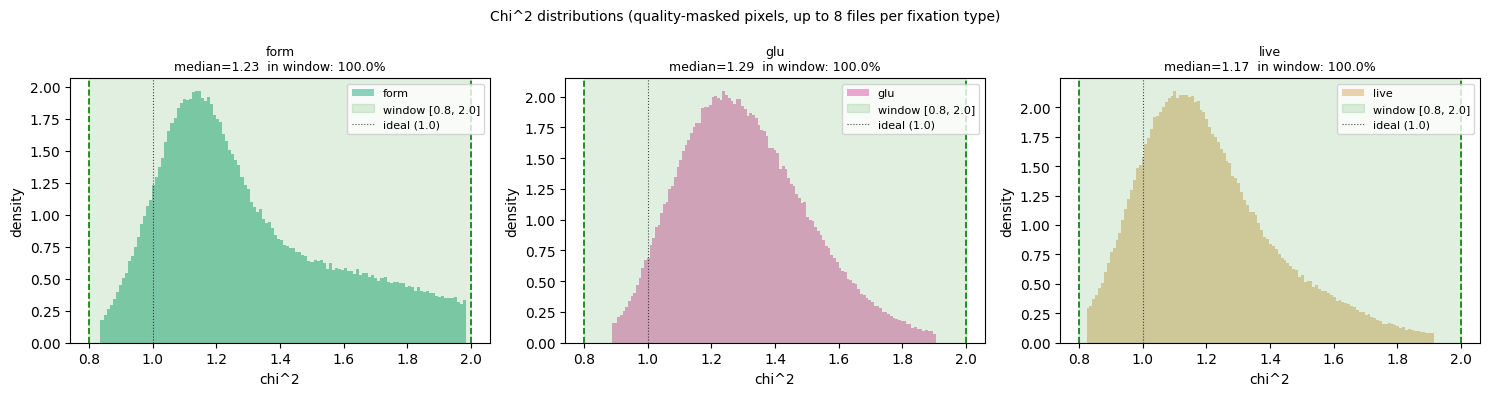

In [7]:
N_CHI2_SAMPLE = 8

chi2_pools = {}

for fix_type in sorted(sample_df["fixation_type"].dropna().unique()):
    sub      = sample_df[sample_df["fixation_type"] == fix_type]
    sampled  = sub.sample(n=min(N_CHI2_SAMPLE, len(sub)), random_state=0)
    arrs     = []
    for _, row in sampled.iterrows():
        key = best_fit_key(row["filename"], fix_type)
        if key is None:
            continue
        fit_dir, _, rel_dir, base_stem = fit_dir_from_key(key)
        if fit_dir is None:
            continue
        fd = load_asc_fit_set(fit_dir, base_stem)
        if not fd or "chi2" not in fd:
            continue
        mask = load_saved_mask(key)
        if mask is None:
            fm = parse_fit_folder(Path(rel_dir).name)
            mask, _ = compute_fit_mask(fd, fix_type, fm["b_val"])
        chi2_arr = fd["chi2"]
        if chi2_arr.shape == mask.shape:
            vals = chi2_arr[mask & np.isfinite(chi2_arr)]
            if vals.size > 0:
                arrs.append(vals)
    if arrs:
        chi2_pools[fix_type] = np.concatenate(arrs)
        print(f"  {fix_type}: {len(arrs)} files, {chi2_pools[fix_type].size:,} pixels")

if chi2_pools:
    n_ft = len(chi2_pools)
    palette_ft = plt.cm.Set2(np.linspace(0, 0.8, n_ft))
    fig, axes  = plt.subplots(1, n_ft, figsize=(5 * n_ft, 4), squeeze=False)

    for ax, (fix_type, vals), col in zip(axes[0], chi2_pools.items(), palette_ft):
        lo_p = max(0.0, float(np.percentile(vals, 0.5)))
        hi_p = min(5.0, float(np.percentile(vals, 99.5)))
        ax.hist(vals, bins=120, range=(lo_p, hi_p), density=True,
                color=col, alpha=0.75, label=fix_type)
        ax.axvspan(CHI2_LO, CHI2_HI, color="green", alpha=0.12,
                   label=f"window [{CHI2_LO}, {CHI2_HI}]")
        ax.axvline(CHI2_LO, color="green", lw=1.2, ls="--")
        ax.axvline(CHI2_HI, color="green", lw=1.2, ls="--")
        ax.axvline(1.0, color="k", lw=0.8, ls=":", alpha=0.7, label="ideal (1.0)")
        pct_in = float(100 * ((vals >= CHI2_LO) & (vals <= CHI2_HI)).mean())
        ax.set_xlabel("chi^2")
        ax.set_ylabel("density")
        ax.set_title(f"{fix_type}\n"
                     f"median={float(np.median(vals)):.2f}  "
                     f"in window: {pct_in:.1f}%", fontsize=9)
        ax.legend(fontsize=8)

    plt.suptitle(
        f"Chi^2 distributions (quality-masked pixels, "
        f"up to {N_CHI2_SAMPLE} files per fixation type)",
        fontsize=10)
    plt.tight_layout()
    plt.show()

## Step 16: Amplitude-weighted tau_mean maps

For each fixation_type, show a representative spatial tau_mean map from
the preferred fit model, alongside the photon image and the quality mask.
tau values are in picoseconds (ps) as exported by SPCImage.

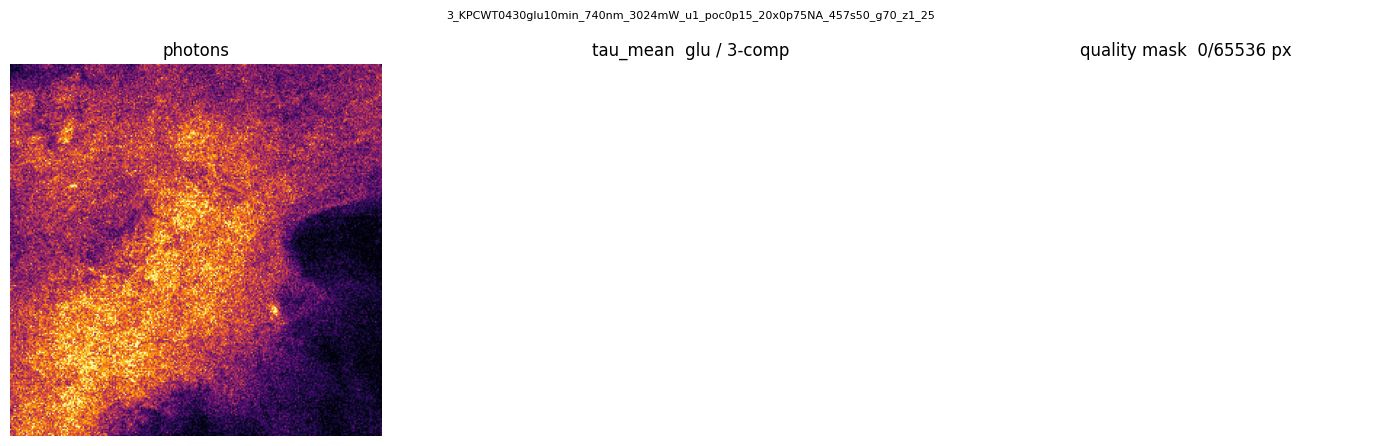

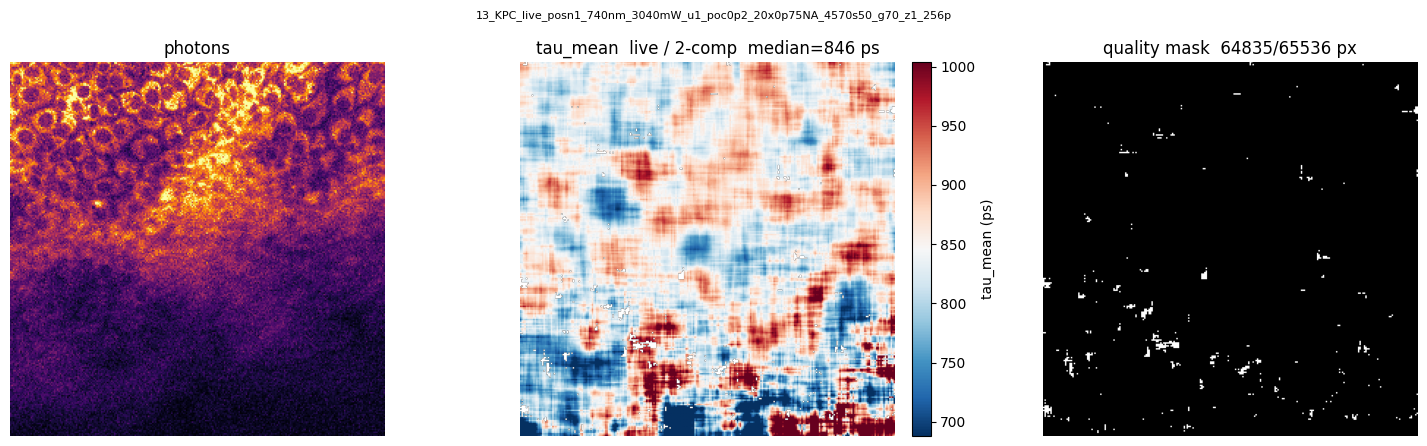

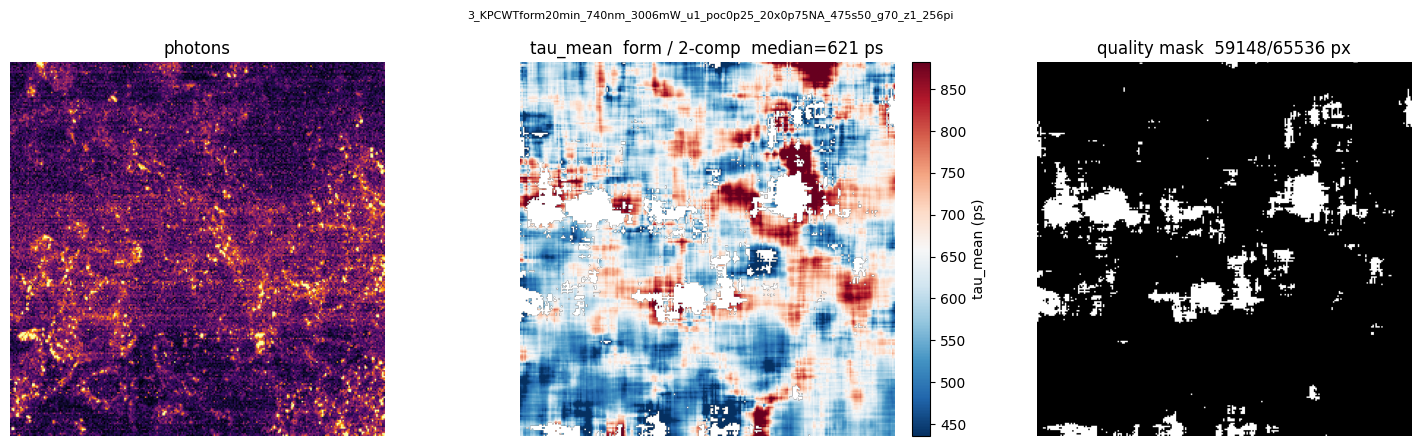

In [8]:
shown = set()

for _, row in sample_df.sort_values("acquisition_time").iterrows():
    fixation_type = row.get("fixation_type")
    key = best_fit_key(row["filename"], fixation_type)
    if key is None:
        continue

    n_comp_rows = fit_map_df[fit_map_df["fit_set_key"] == key]
    n_comp = int(n_comp_rows.iloc[0]["n_components"]) if not n_comp_rows.empty else 0

    gkey = (fixation_type, n_comp)
    if gkey in shown:
        continue

    fit_dir, _, rel_dir, base_stem = fit_dir_from_key(key)
    if fit_dir is None:
        continue

    fd = load_asc_fit_set(fit_dir, base_stem)
    if not fd:
        continue

    mask = load_saved_mask(key)
    if mask is None:
        fm = parse_fit_folder(Path(rel_dir).name)
        mask, _ = compute_fit_mask(fd, fixation_type, fm["b_val"])

    tau_m = compute_tau_mean(fd, fixation_type)
    if tau_m is None:
        print(f"  {fixation_type} {n_comp}-comp: tau_mean unavailable "
              f"(check a2/tau2 and a3/tau3 exports)")
        shown.add(gkey)
        continue

    shown.add(gkey)
    tau_masked = np.where(mask, tau_m, np.nan)
    photons    = fd.get("photons")

    n_panels = 3 if photons is not None else 2
    fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4.5))
    ax_idx = 0

    if photons is not None:
        vmax_p = float(np.percentile(photons[photons > 0], 99))
        axes[ax_idx].imshow(photons, cmap="inferno", vmin=0, vmax=vmax_p)
        axes[ax_idx].set_title("photons")
        axes[ax_idx].axis("off")
        ax_idx += 1

    valid_t = tau_masked[np.isfinite(tau_masked)]
    if valid_t.size > 0:
        vlo = float(np.percentile(valid_t, 2))
        vhi = float(np.percentile(valid_t, 98))
        im  = axes[ax_idx].imshow(tau_masked, cmap="RdBu_r", vmin=vlo, vmax=vhi)
        plt.colorbar(im, ax=axes[ax_idx], label="tau_mean (ps)",
                     fraction=0.046, pad=0.04)
        med_str = f"  median={np.median(valid_t):.0f} ps"
    else:
        med_str = ""
    axes[ax_idx].set_title(f"tau_mean  {fixation_type} / {n_comp}-comp{med_str}")
    axes[ax_idx].axis("off")
    ax_idx += 1

    axes[ax_idx].imshow(mask.astype(float), cmap="gray_r", vmin=0, vmax=1)
    axes[ax_idx].set_title(f"quality mask  {mask.sum()}/{mask.size} px")
    axes[ax_idx].axis("off")

    plt.suptitle(row["filename"][:70], fontsize=8)
    plt.tight_layout()
    plt.show()

## Step 17: tau_mean and amplitude ratio distributions

Pool all quality-masked pixels across all files within each fixation_type
using the preferred fit model. Distributions are in picoseconds (ps).

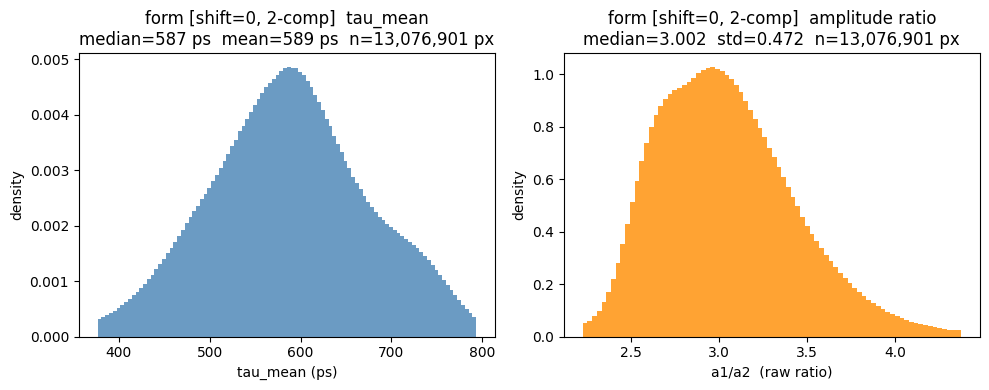

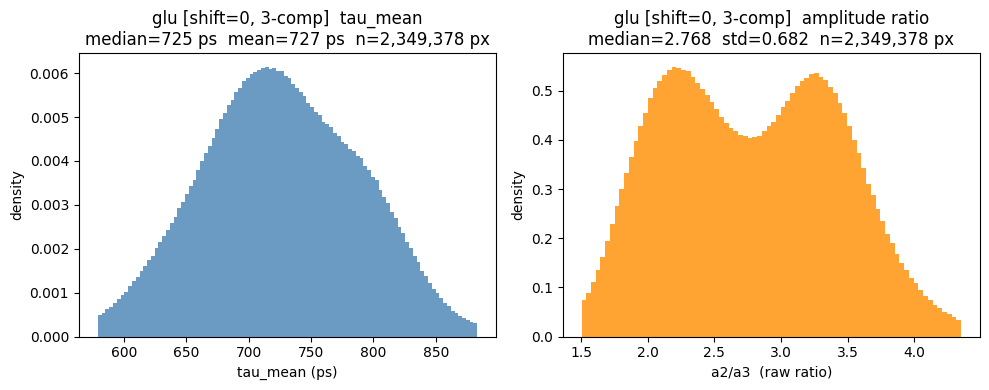

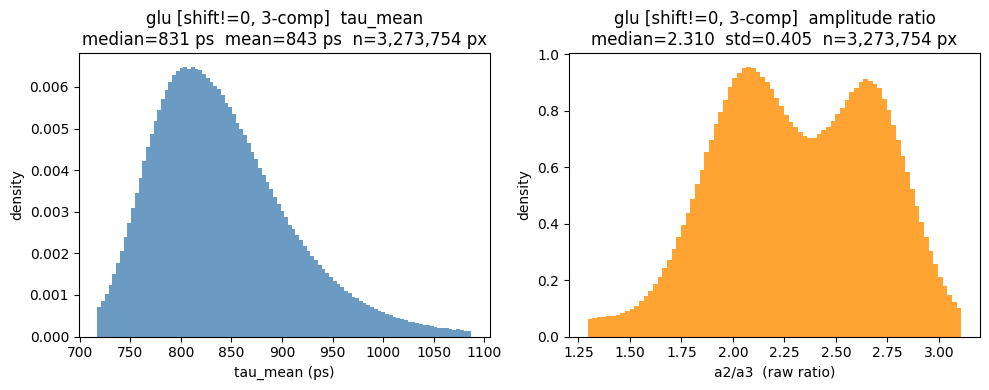

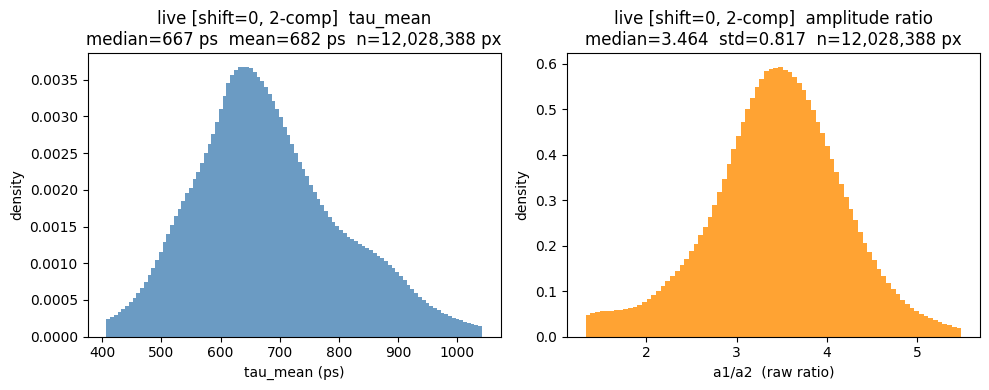

In [9]:
# Pool pixels separately by (fixation_type, shift_group, n_comp) to avoid
# multimodal distributions caused by mixing shift=0/free fits or 2-comp/3-comp models.
# Key: (fixation_type, shift_label, n_comp_str)
tau_pools   = {}
ratio_pools = {}

_shift_sort_17 = {"shift=0": 0, "shift!=0": 1}

for _, row in sample_df.iterrows():
    fixation_type = row.get("fixation_type")
    key = best_fit_key(row["filename"], fixation_type)
    if key is None:
        continue
    fit_dir, _, rel_dir, base_stem = fit_dir_from_key(key)
    if fit_dir is None:
        continue
    fd = load_asc_fit_set(fit_dir, base_stem)
    if not fd:
        continue

    # Determine shift group from the shift array (if exported)
    _shift_arr = fd.get("shift")
    if _shift_arr is not None and np.count_nonzero(np.nan_to_num(_shift_arr)) > 0:
        _sl = "shift!=0"
    else:
        _sl = "shift=0"

    # Determine n_comp from fit_map_df
    _fm = fit_map_df[
        (fit_map_df["sdt_filename"] == row["filename"]) &
        (fit_map_df["fit_set_key"]  == key)
    ]
    _nc = (int(_fm.iloc[0]["n_components"])
           if not _fm.empty and "n_components" in _fm.columns
           else None)
    _nc_str = f"{_nc}-comp" if _nc else "?-comp"
    _gkey = (fixation_type, _sl, _nc_str)

    mask = load_saved_mask(key)
    if mask is None:
        fm = parse_fit_folder(Path(rel_dir).name)
        mask, _ = compute_fit_mask(fd, fixation_type, fm["b_val"])

    tau_m = compute_tau_mean(fd, fixation_type)
    if tau_m is not None:
        vals = tau_m[mask & np.isfinite(tau_m)]
        if vals.size > 0:
            tau_pools.setdefault(_gkey, []).append(vals)

    if fixation_type in RATIO_CFG:
        num_p, den_p = RATIO_CFG[fixation_type]
        if num_p in fd and den_p in fd:
            with np.errstate(invalid="ignore", divide="ignore"):
                ratio = np.where(fd[den_p] > 0, fd[num_p] / fd[den_p], np.nan)
            vals = ratio[mask & np.isfinite(ratio)]
            if vals.size > 0:
                ratio_pools.setdefault(_gkey, []).append(vals)

# Plot one figure per (fixation_type, shift_group, n_comp) combination.
all_gkeys = sorted(
    set(list(tau_pools) + list(ratio_pools)),
    key=lambda x: (x[0], _shift_sort_17.get(x[1], 9), x[2] or ""),
)
for _gkey in all_gkeys:
    ft, _sl, _nc_str = _gkey
    has_tau   = _gkey in tau_pools
    has_ratio = _gkey in ratio_pools
    n_panels  = int(has_tau) + int(has_ratio)
    if n_panels == 0:
        continue

    fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4), squeeze=False)
    col = 0

    if has_tau:
        vals = np.concatenate(tau_pools[_gkey])
        lo   = float(np.percentile(vals[vals > 0], 1)) if (vals > 0).any() else 0.0
        hi   = float(np.percentile(vals, 99))
        axes[0][col].hist(vals, bins=100, range=(lo, hi), density=True,
                          color="steelblue", alpha=0.8)
        axes[0][col].set_xlabel("tau_mean (ps)")
        axes[0][col].set_ylabel("density")
        axes[0][col].set_title(
            f"{ft} [{_sl}, {_nc_str}]  tau_mean\n"
            f"median={np.median(vals):.0f} ps  "
            f"mean={vals.mean():.0f} ps  "
            f"n={len(vals):,} px"
        )
        col += 1

    if has_ratio:
        num_p, den_p = RATIO_CFG[ft]
        vals = np.concatenate(ratio_pools[_gkey])
        _fin = vals[np.isfinite(vals)]
        # Use percentile-based range so glu a2/a3 (typical 1-5) is not clipped.
        # range=(0.0, 1.0) was wrong for glu where ratio >> 1.
        _r_lo = float(np.percentile(_fin, 1))  if _fin.size > 0 else 0.0
        _r_hi = float(np.percentile(_fin, 99)) if _fin.size > 0 else 5.0
        axes[0][col].hist(vals, bins=80, range=(_r_lo, _r_hi), density=True,
                          color="darkorange", alpha=0.8)
        axes[0][col].set_xlabel(f"{num_p}/{den_p}  (raw ratio)")
        axes[0][col].set_ylabel("density")
        axes[0][col].set_title(
            f"{ft} [{_sl}, {_nc_str}]  amplitude ratio\n"
            f"median={np.median(vals):.3f}  "
            f"std={vals.std():.3f}  "
            f"n={len(vals):,} px"
        )

    plt.tight_layout()
    plt.show()

## Step 18: Per-file summary

Compute per-image statistics (tau_mean, amplitude ratio, pixel retention)
using the preferred fit model. Saved to results/fit_analysis_summary.csv.

In [10]:
fit_records = []

for _, row in sample_df.iterrows():
    fixation_type = row.get("fixation_type")
    key = best_fit_key(row["filename"], fixation_type)
    if key is None:
        continue
    if key in _low_ret_keys:
        continue   # < 1% retention; logged in low_retention_warnings.txt
    fit_dir, _, rel_dir, base_stem = fit_dir_from_key(key)
    if fit_dir is None:
        continue
    fd = load_asc_fit_set(fit_dir, base_stem)
    if not fd:
        continue
    fm = parse_fit_folder(Path(rel_dir).name)   # always parse for n_components
    mask = load_saved_mask(key)
    if mask is None:
        mask, _ = compute_fit_mask(fd, fixation_type, fm["b_val"])

    n_final = int(mask.sum())
    n_total = int(mask.size)

    rec = {
        "filename":          row["filename"],
        "session_root":      row.get("session_root"),
        "fixation_type":     fixation_type,
        "cell_type":         row.get("cell_type"),
        "em_filter_nm":      row.get("em_filter_nm"),
        "pockels":           row.get("pockels"),
        "acquisition_time":  row.get("acquisition_time"),
        "fit_set_key":       key,
        "fit_mask_path":     str(fit_dir / f"{base_stem}_fit_mask.npy"),
        "n_components":      fm.get("n_components"),   # explicit column for downstream filtering
        "n_px_total":        n_total,
        "n_px_final":        n_final,
        "pct_final":         round(100.0 * n_final / n_total, 1) if n_total > 0 else np.nan,
    }

    tau_m = compute_tau_mean(fd, fixation_type)
    if tau_m is not None:
        vals = tau_m[mask & np.isfinite(tau_m)]
        mn   = float(vals.mean())     if vals.size > 0 else np.nan
        sd   = float(vals.std())      if vals.size > 0 else np.nan
        rec["tau_mean_median_ps"] = float(np.median(vals)) if vals.size > 0 else np.nan
        rec["tau_mean_mean_ps"]   = mn
        rec["tau_mean_std_ps"]    = sd
        rec["tau_mean_cv"]        = sd / mn if (mn and mn > 0) else np.nan
    else:
        rec.update(tau_mean_median_ps=np.nan, tau_mean_mean_ps=np.nan,
                   tau_mean_std_ps=np.nan, tau_mean_cv=np.nan)

    num_p, den_p = RATIO_CFG.get(fixation_type, (None, None))
    if num_p and den_p and num_p in fd and den_p in fd:
        with np.errstate(invalid="ignore", divide="ignore"):
            ratio = np.where(fd[den_p] > 0, fd[num_p] / fd[den_p], np.nan)
        vals = ratio[mask & np.isfinite(ratio)]
        mn   = float(vals.mean())     if vals.size > 0 else np.nan
        sd   = float(vals.std())      if vals.size > 0 else np.nan
        rec["amp_ratio_median"] = float(np.median(vals)) if vals.size > 0 else np.nan
        rec["amp_ratio_mean"]   = mn
        rec["amp_ratio_std"]    = sd
        rec["amp_ratio_cv"]     = sd / mn if (mn and mn > 0) else np.nan
    else:
        rec.update(amp_ratio_median=np.nan, amp_ratio_mean=np.nan,
                   amp_ratio_std=np.nan, amp_ratio_cv=np.nan)

    fit_records.append(rec)

fit_analysis_df = pd.DataFrame(fit_records)
print(f"Fit analysis summary: {len(fit_analysis_df)} files")
if not fit_analysis_df.empty:
    print(fit_analysis_df.groupby("fixation_type")[
        ["tau_mean_median_ps", "amp_ratio_median", "pct_final"]
    ].mean().round(2).to_string())

fit_analysis_df.to_csv(results_dir / "fit_analysis_summary.csv", index=False)
print(f"\nSaved: {results_dir / 'fit_analysis_summary.csv'}")

Fit analysis summary: 576 files
               tau_mean_median_ps  amp_ratio_median  pct_final
fixation_type                                                 
form                       601.40              2.99      81.44
glu                        787.42              2.48      80.95
live                       668.96              3.41      81.54

Saved: ..\results\fit_analysis_summary.csv


## Snapshot for regression testing

When the env var FLIM_SNAPSHOT is set, dump key intermediate DataFrames
to tests/snapshots/.  Used by tests/compare_outputs.py to catch regressions
during the notebook -> library refactor.  No-op during normal interactive use.

In [11]:
import os as _os
if _os.environ.get("FLIM_SNAPSHOT"):
    _snap_dir = Path(__file__).resolve().parent.parent / "tests" / "snapshots" \
        if "__file__" in dir() else Path("../tests/snapshots")
    _snap_dir.mkdir(parents=True, exist_ok=True)
    mask_summary_df.to_pickle(_snap_dir / "phaseE_mask_summary_df.pkl")
    fit_analysis_df.to_pickle(_snap_dir / "phaseE_fit_analysis_df.pkl")
    print(f"FLIM_SNAPSHOT: wrote phaseE_mask_summary_df.pkl, "
          f"phaseE_fit_analysis_df.pkl to {_snap_dir}")

FLIM_SNAPSHOT: wrote phaseE_mask_summary_df.pkl, phaseE_fit_analysis_df.pkl to ..\tests\snapshots


## Summary

Phase E complete.

Masking pipeline per image (Step 15):
  1. Box-kernel smoothed photon count >= MIN_PHOTONS_SMOOTHED
     Kernel size = (2*b+1) x (2*b+1), b parsed from fit folder name
  2. Chi^2 in [CHI2_LO, CHI2_HI]
  3. Amplitudes >= 0 and sum > 0 (catches SPCImage zero-fill on failed pixels)
  4. Tau values within TAU_BOUNDS[fixation_type] (ps)

Saved in each fit export folder:
  {base_stem}_fit_mask.npy    -- boolean quality mask (one per fit attempt)
  fit_quality_summary.csv     -- per-image mask retention statistics

Saved in results/:
  fit_mask_summary.csv        -- all fit sets, all quality criteria
  fit_analysis_summary.csv    -- per-file tau_mean and amplitude ratio

Before Phase F:
  - If pct_final is consistently < 20%, loosen TAU_BOUNDS or reduce
    MIN_PHOTONS_SMOOTHED
  - Verify tau_mean_median_ps is in the expected NADH range
    (free ~400 ps, bound ~2500 ps; weighted mean typically 1000-2000 ps)
  - For files with both 2-comp and 3-comp fits, compare tau_mean_median_ps
    between models using the n_components column in fit_analysis_summary.csv

In [12]:
import winsound as _ws, time as _t
for _ in range(3):
    _ws.Beep(1000, 400)
    _t.sleep(1)